<a href="https://www.kaggle.com/code/samithsachidanandan/a-network-that-vanishes-vs-not?scriptVersionId=341301159" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


# Create synthetic dataset

In [2]:

np.random.seed(42)
X_train = np.random.randn(1000, 20).astype(np.float32)
y_train = (X_train[:, 0] > 0).astype(np.int64)  # Simple binary classification

X_test = np.random.randn(200, 20).astype(np.float32)
y_test = (X_test[:, 0] > 0).astype(np.int64)

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


# Bad model: Sigmoid, no batch norm, no skip connections

In [3]:

class BadDeepNet(nn.Module):
    def __init__(self, depth=20):
        super().__init__()

        layers = []
        in_dim = 20

        for _ in range(depth):
            layers.append(nn.Linear(in_dim, 64))
            layers.append(nn.Sigmoid())
            in_dim = 64      # <-- IMPORTANT

        layers.append(nn.Linear(64, 2))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Good model: ReLU + Batch Norm

In [4]:

class GoodDeepNet(nn.Module):
    def __init__(self, depth=20):
        super().__init__()

        layers = []
        in_dim = 20

        for _ in range(depth):
            layers.append(nn.Linear(in_dim, 64))
            layers.append(nn.BatchNorm1d(64))
            layers.append(nn.ReLU())
            in_dim = 64      # <-- IMPORTANT

        layers.append(nn.Linear(64, 2))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Train both models

In [5]:

def train_model(model, train_loader, epochs=50, name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"{name} - Epoch {epoch+1}: Loss = {avg_loss:.4f}")
    
    return train_losses

In [6]:
print("Training Bad Model (Sigmoid)...")
bad_model = BadDeepNet(depth=20)
bad_losses = train_model(bad_model, train_loader, epochs=50, name="Bad")

print("\nTraining Good Model (ReLU + BatchNorm)...")
good_model = GoodDeepNet(depth=20)
good_losses = train_model(good_model, train_loader, epochs=50, name="Good")

Training Bad Model (Sigmoid)...
Bad - Epoch 10: Loss = 0.6939
Bad - Epoch 20: Loss = 0.6952
Bad - Epoch 30: Loss = 0.6930
Bad - Epoch 40: Loss = 0.6936
Bad - Epoch 50: Loss = 0.6945

Training Good Model (ReLU + BatchNorm)...
Good - Epoch 10: Loss = 0.6206
Good - Epoch 20: Loss = 0.3243
Good - Epoch 30: Loss = 0.2022
Good - Epoch 40: Loss = 0.1410
Good - Epoch 50: Loss = 0.1256


# Plot

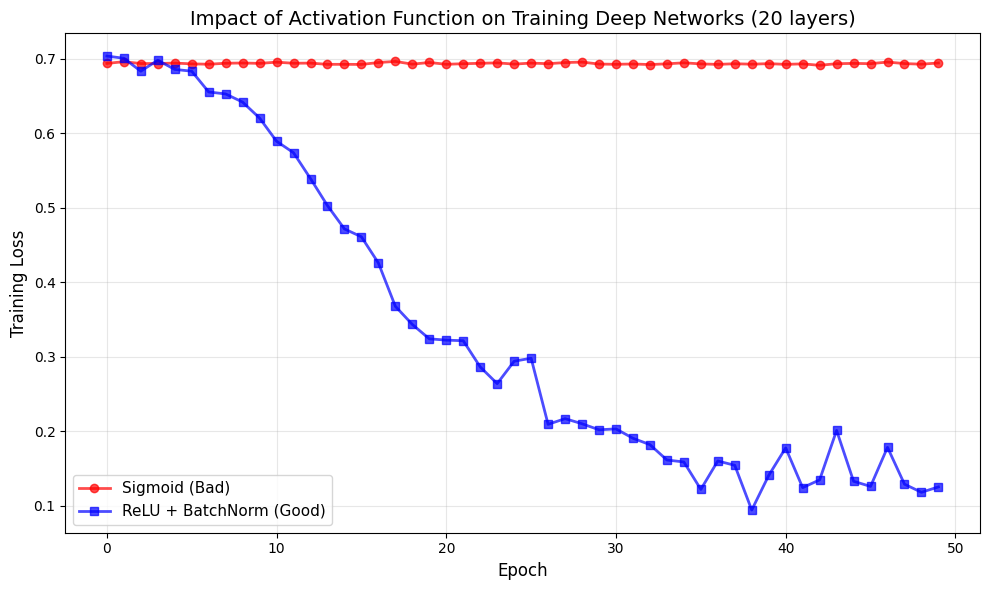

In [7]:

plt.figure(figsize=(10, 6))
plt.plot(bad_losses, 'o-', linewidth=2, label='Sigmoid (Bad)', color='red', alpha=0.7)
plt.plot(good_losses, 's-', linewidth=2, label='ReLU + BatchNorm (Good)', color='blue', alpha=0.7)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Impact of Activation Function on Training Deep Networks (20 layers)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
